In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tabpfn_sbi.methods.tabpfn_sbi import UnconditionalTabPFNSBI
from tabpfn_sbi.tasks.uncond_tasks import UncondDensityEstimationTask
from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS, use_style

work_dir = os.environ.get("WORK")
print(work_dir)


def set_seed(seed: int):
    """This methods just sets the seed."""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


tabpfn_color = DEFAULT_COLORS["filtered_tabpfn"]
npe_color = DEFAULT_COLORS["npe"]

set_seed(42)

/mnt/lustre/work/macke/mwe824


In [4]:
twod_task = UncondDensityEstimationTask("attempto")
prior = twod_task.get_prior_dist()
simulator = twod_task.get_simulator()
prior_samples = prior.sample((100000,))

x = torch.linspace(-4, 4, 100)
y = torch.linspace(-4, 4, 100)
xx, yy = torch.meshgrid(x, y, indexing="ij")
mesh = torch.stack([xx, yy], dim=-1).reshape(-1, 2)

model = UnconditionalTabPFNSBI(num_clusters=15)
model.append_simulations(prior_samples)

log_probs = model.log_prob(mesh, mode="autoregressive")
model_samples = model.sample((10000,))

In [5]:
two_spiral = UncondDensityEstimationTask("2spirals")
ts_prior = two_spiral.get_prior_dist()
ts_simulator = two_spiral.get_simulator()
ts_prior_samples = ts_prior.sample((10000,))

ts_model = UnconditionalTabPFNSBI(num_clusters=1)
ts_model.append_simulations(ts_prior_samples)

ts_log_probs = ts_model.log_prob(mesh, mode="autoregressive")
ts_model_samples = ts_model.sample((10000,))

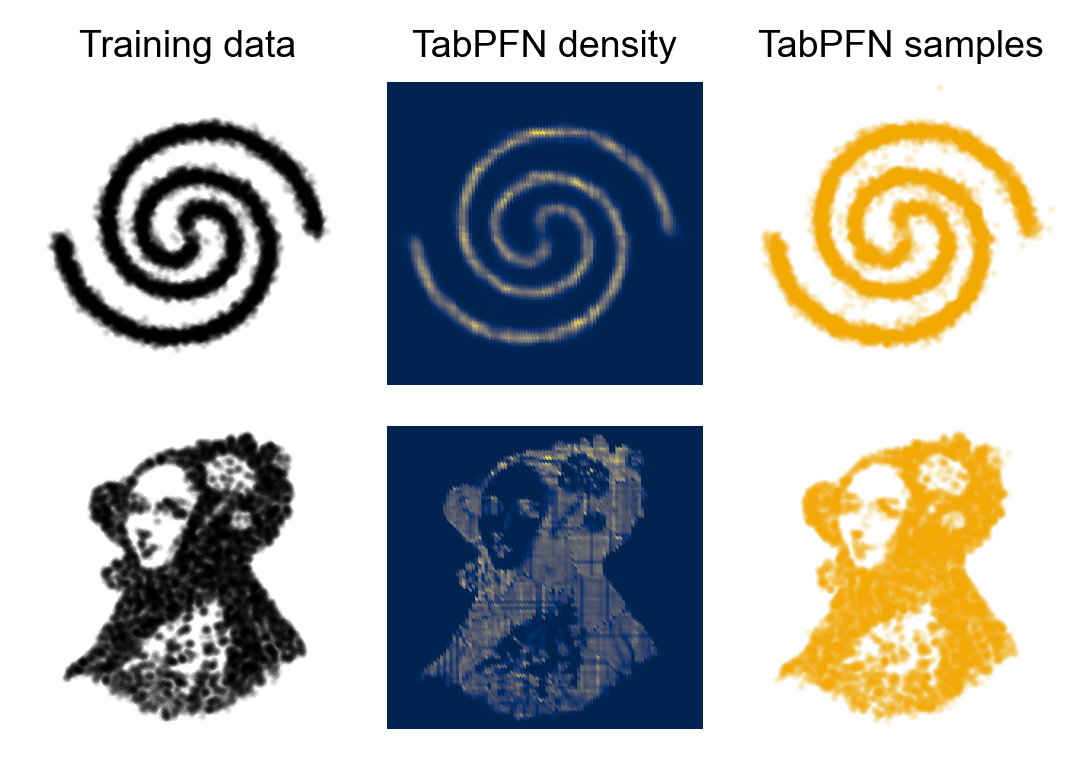

In [ ]:
with use_style("pyloric"):
    fig, axes = plt.subplots(
        2, 3, figsize=(3.7, 2.6), sharex=True, sharey=True, dpi=300
    )
    axes[1, 0].scatter(
        prior_samples[:10000, 0],
        prior_samples[:10000, 1],
        s=1,
        color="black",
        alpha=0.1,
    )
    axes[1, 1].scatter(
        mesh[:, 0], mesh[:, 1], s=1, c=torch.exp(log_probs), cmap="cividis"
    )
    axes[1, 2].scatter(
        model_samples[:, 0], model_samples[:, 1], s=1, color=tabpfn_color, alpha=0.1
    )

    axes[0, 0].scatter(
        ts_prior_samples[:10000, 0],
        ts_prior_samples[:10000, 1],
        s=1,
        color="black",
        alpha=0.1,
    )
    axes[0, 1].scatter(
        mesh[:, 0], mesh[:, 1], s=1, c=torch.exp(ts_log_probs), cmap="cividis"
    )
    axes[0, 2].scatter(
        ts_model_samples[:, 0],
        ts_model_samples[:, 1],
        s=1,
        color=tabpfn_color,
        alpha=0.1,
    )

    for i in range(3):
        for j in range(2):
            axes[j, i].set_xlim(-4, 4)
            axes[j, i].set_ylim(-4, 4)
            axes[j, i].axis("off")

    axes[0, 0].set_title("Training data")
    axes[0, 1].set_title("TabPFN density")
    axes[0, 2].set_title("TabPFN samples")

    fig.tight_layout()
    fig.savefig("fig_unconditional.png", bbox_inches="tight")
    fig.savefig("fig_unconditional.pdf", bbox_inches="tight")
    plt.show()

gas
100 npe 
5
-4.658978509902954
1.8229729130411196
1000 npe 
5
2.7725280284881593
0.553461215935274
10000 npe 
5
7.1044939994812015
0.6285133665024066
100000 npe 
5
10.548451995849609
0.181466722572547
100 uncond_tabpfn 'num_clusters': 1,
5
3.070431280136108
0.20176607268033303
1000 uncond_tabpfn 'num_clusters': 1,
5
7.1075294494628904
0.06560367025916265
100000 uncond_tabpfn 'num_clusters': 1,
5
9.908198356628418
0.0313260060169735
10000 uncond_tabpfn 'num_clusters': 10,
4
10.641332626342773
0.0027530809620324374
100000 uncond_tabpfn 'num_clusters': 10,
4
12.201415538787842
0.03671407254611237
power
100 npe 
5
-4.02095627784729
0.2838851883710747
1000 npe 
5
-0.704162311553955
0.12024089615968979
10000 npe 
5
0.1489129900932312
0.019585709739376053
100000 npe 
5
0.42622998356819153
0.013892482099609704
100 uncond_tabpfn 'num_clusters': 1,
5
-0.86230947971344
0.05959791728061353
1000 uncond_tabpfn 'num_clusters': 1,
5
-0.2335791230201721
0.04666188243009791
100000 uncond_tabpfn 'num_

/tmp/ipykernel_1478944/2480224636.py:102: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


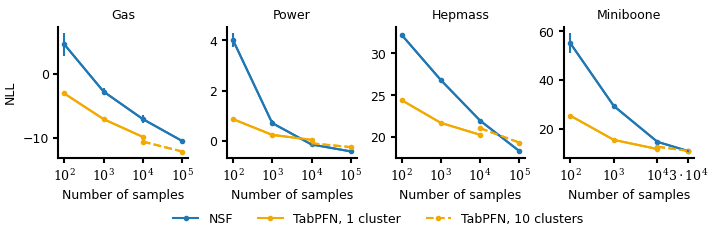

In [12]:
# TODO add to main results
df = pd.read_csv(os.path.join(work_dir, "tabpfn_sbi/results/uncond_uci/summary.csv"))

with use_style("pyloric"):
    fig, axs = plt.subplots(1, 4, figsize=(8.2, 1.7))

    for idx, task in enumerate(["gas", "power", "hepmass", "miniboone"]):
        cond_list = [
            (100, "npe", ""),
            (1000, "npe", ""),
            (10000, "npe", ""),
            (100000, "npe", ""),
            (100, "uncond_tabpfn", "'num_clusters': 1,"),
            (1000, "uncond_tabpfn", "'num_clusters': 1,"),
            (100000, "uncond_tabpfn", "'num_clusters': 1,"),
            (10000, "uncond_tabpfn", "'num_clusters': 10,"),
            (100000, "uncond_tabpfn", "'num_clusters': 10,"),
        ]

        means = []
        stds = []
        print(task)
        print("======================")
        for num_simulations, method, subs in cond_list:
            print(num_simulations, method, subs)
            sub_df = df[
                (df["task"] == task)
                & (df["num_simulations"] == num_simulations)
                & (df["method"] == method)
                & df["cfg"].str.contains(subs, na=False)
            ]
            print(len(sub_df))
            mean_val = sub_df["value"].str.strip("[]").astype(float)
            print(mean_val.mean())
            print(mean_val.std())
            means.append(-mean_val.mean())
            stds.append(mean_val.std())
            print("======================")

        axs[idx].plot(
            [0, 1, 2, 2.7] if task == "miniboone" else [0, 1, 2, 3],
            means[:4],
            label="NSF",
            marker="o",
            color=npe_color,
        )
        axs[idx].errorbar(
            [0, 1, 2, 2.7] if task == "miniboone" else [0, 1, 2, 3],
            means[:4],
            yerr=stds[:4],
            color=npe_color,
        )
        axs[idx].plot(
            [0, 1, 2],
            means[4:7],
            label="TabPFN, 1 cluster",
            marker="o",
            color=tabpfn_color,
        )
        axs[idx].errorbar(
            [0, 1, 2],
            means[4:7],
            yerr=stds[4:7],
            color=tabpfn_color,
        )
        axs[idx].plot(
            [2, 2.7] if task == "miniboone" else [2, 3],
            means[7:9],
            label="TabPFN, 10 clusters",
            linestyle="--",
            marker="o",
            color=tabpfn_color,
        )
        axs[idx].errorbar(
            [2, 2.7] if task == "miniboone" else [2, 3],
            means[7:9],
            yerr=stds[7:9],
            color=tabpfn_color,
            linestyle="--",
        )
        axs[idx].set_xticks([0, 1, 2, 2.7] if task == "miniboone" else [0, 1, 2, 3])
        axs[idx].set_xticklabels(
            [
                r"$10^2$",
                r"$10^3$",
                r"$10^4$",
                r"$3 \cdot 10^4$" if task == "miniboone" else r"$10^5$",
            ]
        )
        axs[idx].set_xlabel("Number of samples")
        axs[idx].set_title(task.capitalize())
        if idx == 0:
            axs[idx].set_ylabel("NLL")
        if idx == 0:
            axs[idx].legend(
                loc="lower left",
                bbox_to_anchor=(0.8, -0.6),
                ncol=3,
            )

    fig.subplots_adjust(wspace=0.3)
    fig.tight_layout()
    fig.savefig("uci_results.svg", bbox_inches="tight")